In [1]:
pip install wquantiles

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import trim_mean
import wquantiles 
from statsmodels import robust

In [7]:
data = {
    "state" : ['A','B', 'C','D','E','F','G','H'],
    'population' : [3_000_000, 7_000_000, 12_000_000, 25_000_000, 40_000_000, 5_000_000, 8_000_000, 18_000_000],
    'murder.Rate' : [3.2, 5.5, 2.8, 6.7, 4.0, 5.0, 7.1, 4.5]
}
state = pd.DataFrame(data)
state.head()

,state,population,murder.Rate
0,A,3000000,3.2
1,B,7000000,5.5
2,C,12000000,2.8
3,D,25000000,6.7
4,E,40000000,4.0


In [8]:
print("Mean population", state['population'].mean())
print("median population", state['population'].median())
print("Trimed mean population", trim_mean(state['population'], 0.1))

Mean population 14750000.0
median population 10000000.0
Trimed mean population 14750000.0


In [9]:
print("weighted mean murder rate", np.average(state['murder.Rate'], weights=state['population']))
print("weighted median murder rate", wquantiles.median(state['murder.Rate'], weights=state['population']))


weighted mean murder rate 4.8474576271186445
weighted median murder rate 4.413793103448276


In [12]:
print("sd ", state['population'].std())
print("IQR {:.2f}".format(state['population'].quantile(0.75) - state['population'].quantile(0.25)))
print("MAD {:.2f}".format(robust.scale.mad(state['population'])))

sd  12532814.072323445
IQR 13250000.00
MAD 8895613.31


In [15]:
print("murder rate quantile\n",state['murder.Rate'].quantile([0.05, 0.25,0.5, 0.75, 0.95]))

murder rate quantile
 0.05    2.94
0.25    3.80
0.50    4.75
0.75    5.80
0.95    6.96
Name: murder.Rate, dtype: float64


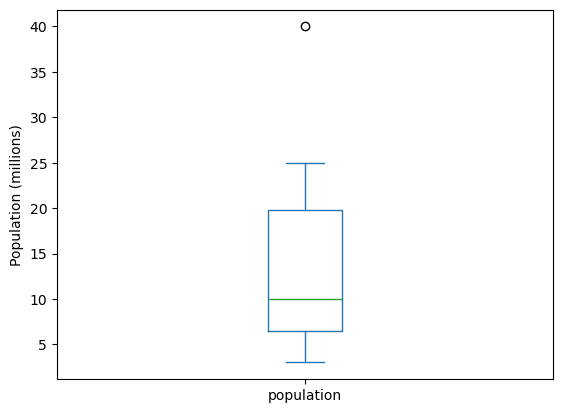

In [16]:
ax = (state['population']/1_000_000).plot.box()
ax.set_ylabel("Population (millions)") 
plt.show()

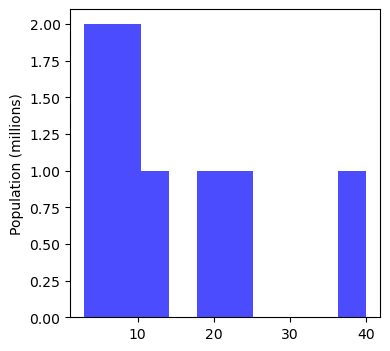

In [19]:
ax = (state['population']/1_000_000).plot.hist(figsize = (4,4),alpha=0.7, color='blue')
ax.set_ylabel("Population (millions)") 
plt.show()

In [ ]:
ax = (state['population']/1_000_000).plot.hist(figsize = (4,4),alpha=0.7, color='blue')
ax.set_ylabel("Population (millions)") 
plt.show()